# 📊 **EDA Comercial — Seed a Bit (2022–2026)**
>**Análise Exploratória de Dados da Área Comercial**

* 👥 **Autor(a)**: Luiz Vinicius - Candidado à Diretoria de Negócios
* 🎯 **Objetivo**: Este notebook tem como objetivo organizar os dados e gerar insights sobre a área comercial da Seed a Bit. A partir disso, auxiliar o(a) candidato(a) na elaboração de soluções com base em dados para seu desafio do Processo Eleitoral.
* OBS: Os nomes reais dos contratos foram anonimizados.
* 🗺️ **Sumário de Navegação**:

| Seção | Descrição | Status |
| :--- | :--- | :---: |
| [**0. Setup e Preparação**](#0.-Setup-e-Prepara%C3%A7%C3%A3o-dos-Dados) | Importação de bibliotecas, definição de estilo visual e carga dos dados. | OK |
| [**1. Análise Univariada**](#1.-An%C3%A1lise-Univariada) | Distribuição de faturamento, tickets médios e sazonalidade histórica. | OK |
| [**2. Análise Bivariada/Multivariada**](#2.-An%C3%A1lise-Bivariada-e-Multivariada) | Cruzamentos estratégicos: Origem x Serviço, Ritmo e Composição. | OK |
| [**3. Insights Comerciais**](#3.-Insights-Comerciais) | Síntese analítica e conclusões estratégicas para tomada de decisão. | OK |

---

## 0. Setup e Preparação dos Dados

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Estilo global
BG       = "#0D1B2E"
CARD     = "#132035"
ACCENT   = "#F0C040"
TEXT     = "#C8D4E0"
GRID     = "#1E3050"

PALETTE  = ["#F0C040","#5DCAA5","#AFA9EC","#ED93B1","#FAC775","#64B5F6","#FF8A65"]
ORIGENS  = ["institucional","indicação","prospecção_ativa","recorrência","marketing"]
ORI_COL  = dict(zip(ORIGENS, PALETTE))

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    CARD,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "text.color":        TEXT,
    "grid.color":        GRID,
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

def fmt_brl(x, pos=None):
    return f"R$ {x:,.0f}".replace(",",".")

def save(name):
    # Corrigido para o path do Colab
    plt.savefig(f"/content/{name}.png", dpi=150, bbox_inches="tight",
                facecolor=BG)
    plt.show()
    plt.close()

print("Setup OK ✓ (Caminho de salvamento corrigido)")

Setup OK ✓ (Caminho de salvamento corrigido)


In [ ]:
import pandas as pd

# Dados com nomes fictícios
dados2022 = [
    {"cliente": "Tech Synergy", "faturamento": 4000,  "colaborativo": 1, "origem": "institucional",   "servico": "concepção",        "data": "04-2022"},
    {"cliente": "Tech Synergy", "faturamento": 1280,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "04-2022"},
    {"cliente": "Horizon Consult", "faturamento": 2429,  "colaborativo": 1, "origem": "institucional",   "servico": "site",             "data": "05-2022"},
    {"cliente": "Tech Synergy", "faturamento": 1280,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "06-2022"},
    {"cliente": "Tech Synergy", "faturamento": 1280,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "07-2022"},
    {"cliente": "BioLabs Solutions", "faturamento": 235,   "colaborativo": 0, "origem": "indicação",       "servico": "site",             "data": "07-2022"},
    {"cliente": "Alpha Tech Assoc.", "faturamento": 10000, "colaborativo": 1, "origem": "institucional",   "servico": "concepção",        "data": "08-2022"},
    {"cliente": "Tech Synergy", "faturamento": 2464,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "10-2022"},
]
dados2023 = [
    {"cliente": "Global Connect", "faturamento": 2700, "colaborativo": 0, "origem": "institucional",   "servico": "concepção",        "data": "01-2023"},
    {"cliente": "Eco Innovate", "faturamento": 9600, "colaborativo": 1, "origem": "indicação",       "servico": "concepção",        "data": "04-2023"},
    {"cliente": "Junior Insight", "faturamento": 200,  "colaborativo": 1, "origem": "institucional",   "servico": "consultoria",      "data": "05-2023"},
    {"cliente": "Marta Cavalcanti", "faturamento": 2610, "colaborativo": 0, "origem": "indicação",       "servico": "site",             "data": "06-2023"},
    {"cliente": "Core Systems", "faturamento": 3564, "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "07-2023"},
    {"cliente": "Spark Energy", "faturamento": 2800, "colaborativo": 0, "origem": "prospecção_ativa","servico": "site",             "data": "08-2023"},
    {"cliente": "DataWise Solutions", "faturamento": 2400, "colaborativo": 1, "origem": "prospecção_ativa","servico": "site",             "data": "08-2023"},
    {"cliente": "Marta Cavalcanti", "faturamento": 600,  "colaborativo": 1, "origem": "recorrência",       "servico": "site",             "data": "08-2023"},
    {"cliente": "Mining Tech Jr", "faturamento": 2800, "colaborativo": 0, "origem": "prospecção_ativa","servico": "site",             "data": "09-2023"},
    {"cliente": "Marta Cavalcanti", "faturamento": 750,  "colaborativo": 0, "origem": "recorrência",     "servico": "site",             "data": "09-2023"},
    {"cliente": "Fenix Research", "faturamento": 7200, "colaborativo": 1, "origem": "institucional",   "servico": "concepção",        "data": "10-2023"},
    {"cliente": "Business Flow", "faturamento": 2000, "colaborativo": 1, "origem": "institucional",   "servico": "site",             "data": "11-2023"},
]
dados2024 = [
    {"cliente": "Global Connect", "faturamento": 2850,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "01-2024"},
    {"cliente": "Sales Network Plus", "faturamento": 3500,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "site",             "data": "01-2024"},
    {"cliente": "Fenix Research", "faturamento": 18500, "colaborativo": 1, "origem": "institucional",   "servico": "concepção",        "data": "02-2024"},
    {"cliente": "Engenious Consult", "faturamento": 3200,  "colaborativo": 1, "origem": "institucional",   "servico": "site",             "data": "04-2024"},
    {"cliente": "Solaris Corp", "faturamento": 2200,  "colaborativo": 1, "origem": "indicação",       "servico": "site",             "data": "04-2024"},
    {"cliente": "Global Connect", "faturamento": 950,   "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "06-2024"},
    {"cliente": "Juliana Mendes", "faturamento": 2200,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "site",             "data": "06-2024"},
    {"cliente": "Global Connect", "faturamento": 2850,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "08-2024"},
    {"cliente": "Legal Strategy", "faturamento": 2850,  "colaborativo": 0, "origem": "indicação",       "servico": "site",             "data": "08-2024"},
    {"cliente": "Vânia Santos", "faturamento": 3610,  "colaborativo": 0, "origem": "indicação",       "servico": "site",             "data": "10-2024"},
    {"cliente": "Tempo Real", "faturamento": 2200,  "colaborativo": 1, "origem": "institucional",   "servico": "site",             "data": "10-2024"},
    {"cliente": "Ver-Tech", "faturamento": 8200,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "concepção",        "data": "11-2024"},
    {"cliente": "Global Connect", "faturamento": 3800,  "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "11-2024"},
]
dados2025 = [
    {"cliente": "Beta Lab", "faturamento": 300,    "colaborativo": 0, "origem": "institucional",   "servico": "concessão_de_time","data": "01-2025"},
    {"cliente": "Beta Lab Regional", "faturamento": 3636,   "colaborativo": 1, "origem": "institucional",   "servico": "concessão_de_time","data": "02-2025"},
    {"cliente": "Solar Power", "faturamento": 3325,   "colaborativo": 0, "origem": "indicação",       "servico": "prototipação",     "data": "03-2025"},
    {"cliente": "WebCloud Hosting", "faturamento": 11176,  "colaborativo": 0, "origem": "indicação",       "servico": "mobile",           "data": "03-2025"},
    {"cliente": "WebCloud Hosting", "faturamento": 1597,   "colaborativo": 0, "origem": "recorrência",     "servico": "mobile",           "data": "04-2025"},
    {"cliente": "Agility UX", "faturamento": 2500,   "colaborativo": 0, "origem": "prospecção_ativa","servico": "concepção",        "data": "05-2025"},
    {"cliente": "Health Plus", "faturamento": 28215,  "colaborativo": 1, "origem": "prospecção_ativa","servico": "mobile",           "data": "05-2025"},
    {"cliente": "Ricardo Oliveira", "faturamento": 550,    "colaborativo": 0, "origem": "indicação",       "servico": "consultoria",      "data": "07-2025"},
    {"cliente": "Health Plus", "faturamento": 2700,   "colaborativo": 0, "origem": "recorrência",     "servico": "mobile",           "data": "07-2025"},
    {"cliente": "Z-Digital", "faturamento": 5590.8, "colaborativo": 0, "origem": "indicação",       "servico": "concepção",        "data": "07-2025"},
    {"cliente": "WebCloud Hosting", "faturamento": 7874,   "colaborativo": 0, "origem": "recorrência",     "servico": "sistema_web",      "data": "07-2025"},
    {"cliente": "Market Master", "faturamento": 3650,   "colaborativo": 0, "origem": "institucional",   "servico": "site",             "data": "08-2025"},
    {"cliente": "Carlos Eduardo", "faturamento": 15100,  "colaborativo": 1, "origem": "prospecção_ativa","servico": "sistema_web",      "data": "08-2025"},
    {"cliente": "Nexus Tech", "faturamento": 2200,   "colaborativo": 0, "origem": "institucional",   "servico": "site",             "data": "10-2025"},
    {"cliente": "Insight Software", "faturamento": 2000,   "colaborativo": 0, "origem": "prospecção_ativa","servico": "site",             "data": "10-2025"},
    {"cliente": "Stelar Agency", "faturamento": 2600,   "colaborativo": 0, "origem": "marketing",       "servico": "site",             "data": "11-2025"},
]
dados2026 = [
    {"cliente": "BioCare Med", "faturamento": 1500,  "colaborativo": 0, "origem": "indicação",       "servico": "manutenção",  "data": "01-2026"},
    {"cliente": "BioCare Med", "faturamento": 600,   "colaborativo": 0, "origem": "recorrência",     "servico": "manutenção",  "data": "03-2026"},
    {"cliente": "Dynamic Fitness", "faturamento": 5800,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "concepção",   "data": "03-2026"},
    {"cliente": "Voxel Studio", "faturamento": 5800,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "concepção",   "data": "04-2026"},
    {"cliente": "BioCare Med", "faturamento": 600,   "colaborativo": 0, "origem": "recorrência",     "servico": "manutenção",  "data": "04-2026"},
    {"cliente": "Luminous Clinic", "faturamento": 250,   "colaborativo": 1, "origem": "institucional",   "servico": "manutenção",  "data": "04-2026"},
    {"cliente": "Carlos Eduardo", "faturamento": 4500,  "colaborativo": 1, "origem": "recorrência",     "servico": "manutenção",  "data": "04-2026"},
    {"cliente": "Elite Logistics", "faturamento": 1850,  "colaborativo": 1, "origem": "prospecção_ativa","servico": "automação",   "data": "05-2026"},
    {"cliente": "Elite Logistics", "faturamento": 4200,  "colaborativo": 0, "origem": "prospecção_ativa","servico": "manutenção",  "data": "05-2026"},
    {"cliente": "BioCare Med", "faturamento": 1200,  "colaborativo": 0, "origem": "recorrência",     "servico": "manutenção",  "data": "05-2026"},
    {"cliente": "Prime Development", "faturamento": 24850, "colaborativo": 1, "origem": "recorrência",     "servico": "sistema_web", "data": "05-2026"},
    {"cliente": "Visionary Lab", "faturamento": 1200,  "colaborativo": 1, "origem": "institucional",   "servico": "site",        "data": "05-2026"},
    {"cliente": "BioCare Med", "faturamento": 1800,  "colaborativo": 0, "origem": "recorrência",   "servico": "manutenção",        "data": "06-2026"},
    {"cliente": "Henrique Lima", "faturamento": 300,  "colaborativo": 0, "origem": "Institucional",   "servico": "prototipação",        "data": "06-2026"},
]

metas = {
    2022: {"meta_anual": 6782,  "faturamento_total": 22968.66},
    2023: {"meta_anual": 30000, "faturamento_total": 37224.00},
    2024: {"meta_anual": 50000, "faturamento_total": 56910.00},
    2025: {"meta_anual": 40000, "faturamento_total": 94013.80},
    2026: {"meta_anual": 98715, "faturamento_total_ate_momento": 52350.00},
}

ritmo = {
    2022: [565.16,1130.32,1695.48,2260.64,2825.80,3390.96,3956.12,4521.28,5086.44,5651.6,6216.76,6782],
    2023: [2500,5000,7500,10000,12500,15000,17500,20000,22500,25000,27500,30000],
    2024: [4166.67,8333.33,12500,16666.67,20833.33,25000,29166.67,33333.33,37500,41666.67,45833.33,50000],
    2025: [3333.33,6666.66,10000,13333.33,16666.66,20000,23333.33,26666.66,30000,33333.33,36666.66,40000],
    2026: [8226.25,16452.5,24678.75,32905,41131.25,49357.5,57583.75,65810,74036.25,82262.5,90488.75,98715],
}

all_data = []
for ano, dados in [(2022,dados2022),(2023,dados2023),(2024,dados2024),(2025,dados2025),(2026,dados2026)]:
    for d in dados:
        row = d.copy()
        row["ano"] = ano
        mm = int(d["data"].split("-")[0])
        row["mes_num"] = mm
        all_data.append(row)

df = pd.DataFrame(all_data)
df["data_dt"] = pd.to_datetime(df["data"], format="%m-%Y")
df["origem"] = df["origem"].replace("", "não informado")
df["servico"] = df["servico"].replace("", "não informado")

print("DataFrame criado com", len(df), "contratos (Nomes Anonimizados)")
display(df[["ano","cliente","faturamento","servico","origem"]].head())

DataFrame criado com 63 contratos (Nomes Anonimizados)


,ano,cliente,faturamento,servico,origem
0,2022,Tech Synergy,4000.0,concepção,institucional
1,2022,Tech Synergy,1280.0,concessão_de_time,institucional
2,2022,Horizon Consult,2429.0,site,institucional
3,2022,Tech Synergy,1280.0,concessão_de_time,institucional
4,2022,Tech Synergy,1280.0,concessão_de_time,institucional


---
## 1. Análise Univariada
> Distribuição individual de cada variável — faturamento, tipo de serviço, origem e sazonalidade.


### 1.1 Distribuição dos valores de contrato

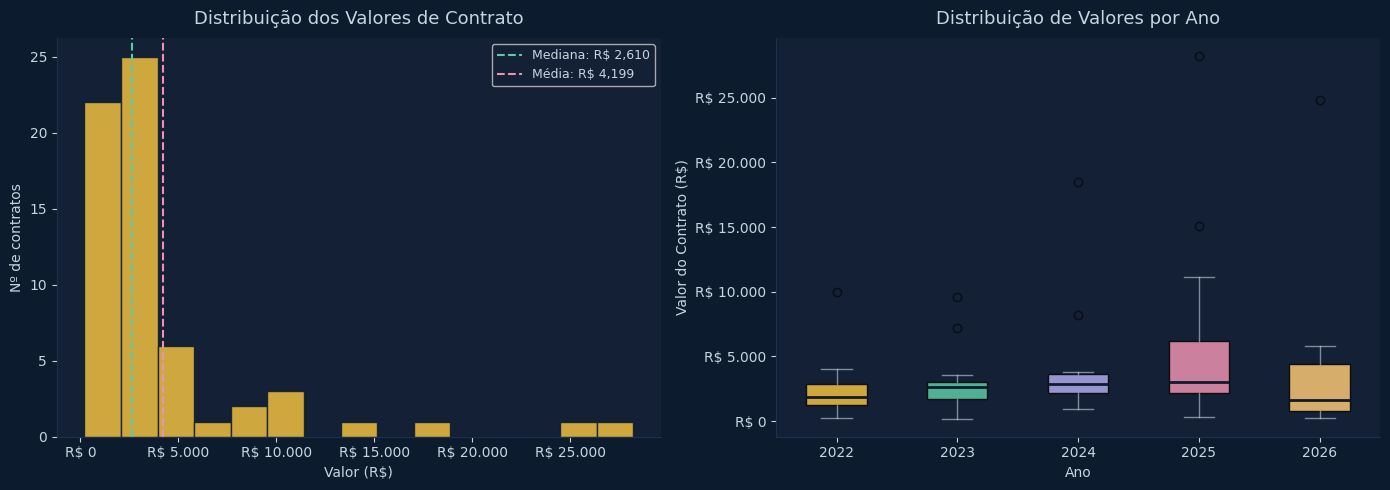

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

# Histograma
ax = axes[0]
ax.set_facecolor(CARD)
n, bins, patches = ax.hist(df["faturamento"], bins=15, color=ACCENT, edgecolor=BG, alpha=0.85)
ax.set_title("Distribuição dos Valores de Contrato", color=TEXT, fontsize=13, pad=10)
ax.set_xlabel("Valor (R$)", color=TEXT)
ax.set_ylabel("Nº de contratos", color=TEXT)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.axvline(df["faturamento"].median(), color="#5DCAA5", linestyle="--", linewidth=1.5,
           label=f"Mediana: R$ {df['faturamento'].median():,.0f}")
ax.axvline(df["faturamento"].mean(), color="#ED93B1", linestyle="--", linewidth=1.5,
           label=f"Média: R$ {df['faturamento'].mean():,.0f}")
ax.legend(fontsize=9)

# Boxplot por ano
ax2 = axes[1]
ax2.set_facecolor(CARD)
anos = sorted(df["ano"].unique())
data_box = [df[df["ano"]==a]["faturamento"].values for a in anos]
bp = ax2.boxplot(data_box, patch_artist=True, labels=anos,
                 medianprops=dict(color=BG, linewidth=2))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(PALETTE[i % len(PALETTE)])
    patch.set_alpha(0.85)
for element in ["whiskers","caps","fliers"]:
    for item in bp[element]:
        item.set_color(TEXT)
        item.set_alpha(0.6)
ax2.set_title("Distribuição de Valores por Ano", color=TEXT, fontsize=13, pad=10)
ax2.set_xlabel("Ano", color=TEXT)
ax2.set_ylabel("Valor do Contrato (R$)", color=TEXT)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))

plt.tight_layout()
save("u1_distribuicao_faturamento")


### 1.2 Faturamento total anual vs Meta

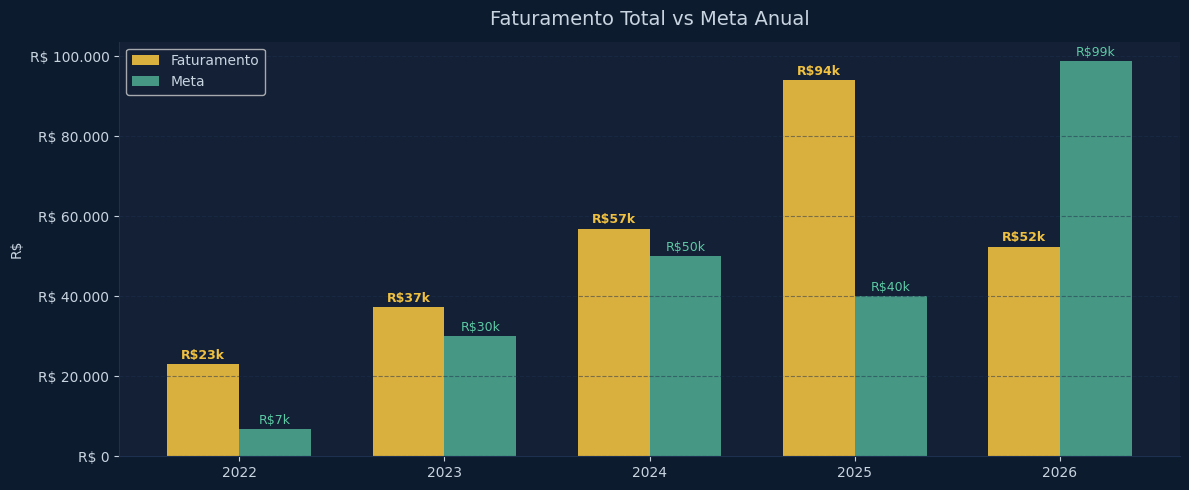

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

anos = sorted(metas.keys())
fat  = [metas[a].get("faturamento_total", metas[a].get("faturamento_total_ate_momento")) for a in anos]
meta = [metas[a]["meta_anual"] for a in anos]

x = np.arange(len(anos))
w = 0.35
bars1 = ax.bar(x - w/2, fat,  w, label="Faturamento",  color=ACCENT,   alpha=0.9)
bars2 = ax.bar(x + w/2, meta, w, label="Meta",          color="#5DCAA5",alpha=0.7)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+600,
            f"R${bar.get_height()/1000:.0f}k", ha="center", va="bottom",
            color=ACCENT, fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+600,
            f"R${bar.get_height()/1000:.0f}k", ha="center", va="bottom",
            color="#5DCAA5", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(anos)
ax.set_title("Faturamento Total vs Meta Anual", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(fontsize=10)
ax.grid(axis="y")
plt.tight_layout()
save("u2_faturamento_vs_meta")


### 1.3 Ticket médio por ano

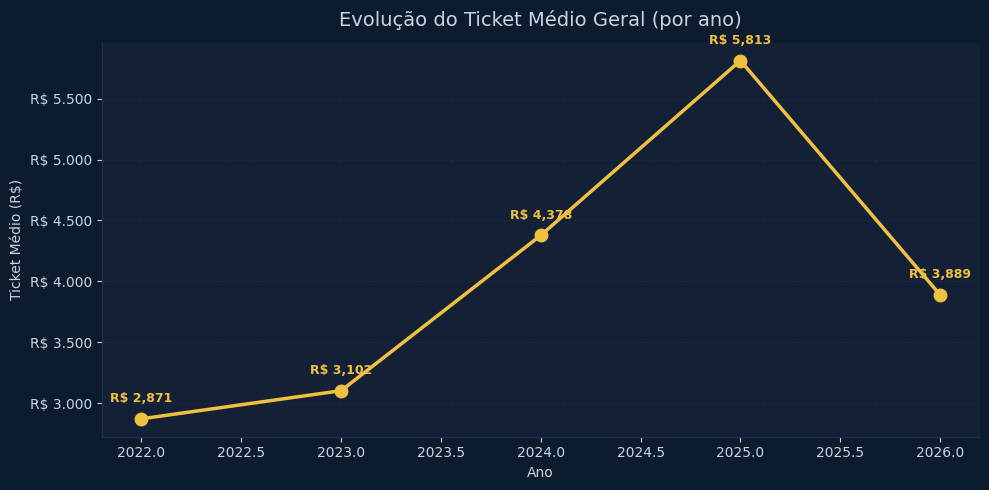

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

tm = df.groupby("ano")["faturamento"].mean().reset_index()
ax.plot(tm["ano"], tm["faturamento"], marker="o", color=ACCENT,
        linewidth=2.5, markersize=9)
for _, row in tm.iterrows():
    ax.annotate(f"R$ {row['faturamento']:,.0f}", (row["ano"], row["faturamento"]),
                textcoords="offset points", xytext=(0, 12),
                ha="center", color=ACCENT, fontsize=9, fontweight="bold")
ax.set_title("Evolução do Ticket Médio Geral (por ano)", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Ticket Médio (R$)", color=TEXT)
ax.set_xlabel("Ano", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.grid(axis="y")
plt.tight_layout()
save("u3_ticket_medio_por_ano")


### 1.4 Ticket médio por tipo de serviço

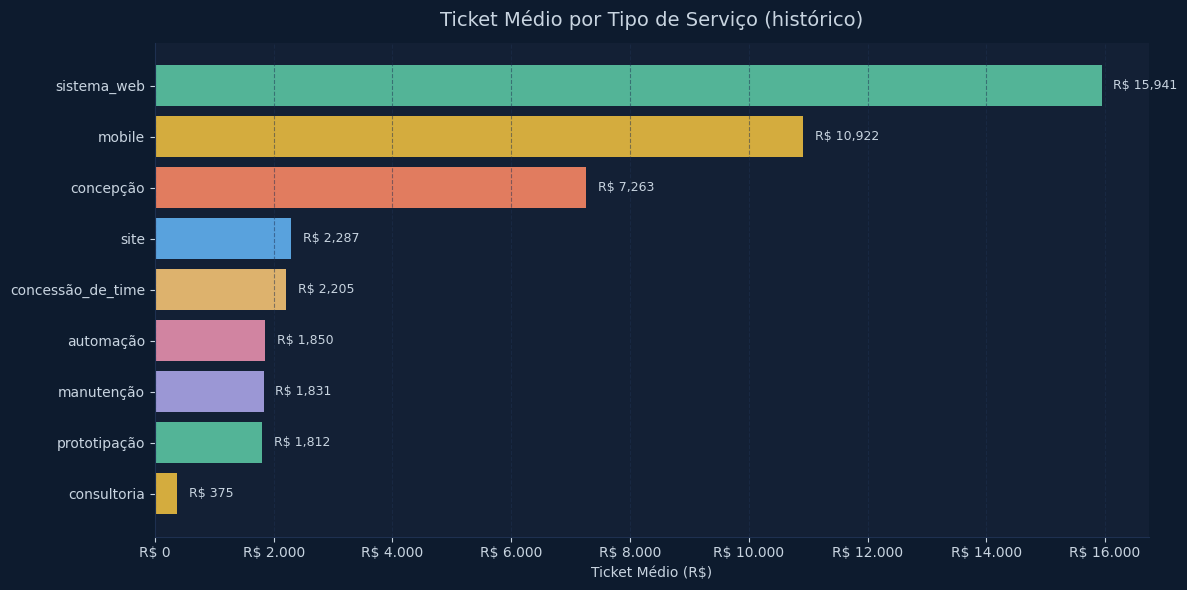

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

tm_serv = (df.groupby("servico")["faturamento"]
             .mean()
             .sort_values(ascending=True)
             .reset_index())
colors = [PALETTE[i % len(PALETTE)] for i in range(len(tm_serv))]
bars = ax.barh(tm_serv["servico"], tm_serv["faturamento"], color=colors, alpha=0.88)
for bar, val in zip(bars, tm_serv["faturamento"]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f"R$ {val:,.0f}", va="center", color=TEXT, fontsize=9)
ax.set_title("Ticket Médio por Tipo de Serviço (histórico)", color=TEXT, fontsize=14, pad=12)
ax.set_xlabel("Ticket Médio (R$)", color=TEXT)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.grid(axis="x")
plt.tight_layout()
save("u4_ticket_medio_por_servico")


### 1.5 Frequência de tipos de serviço vendidos

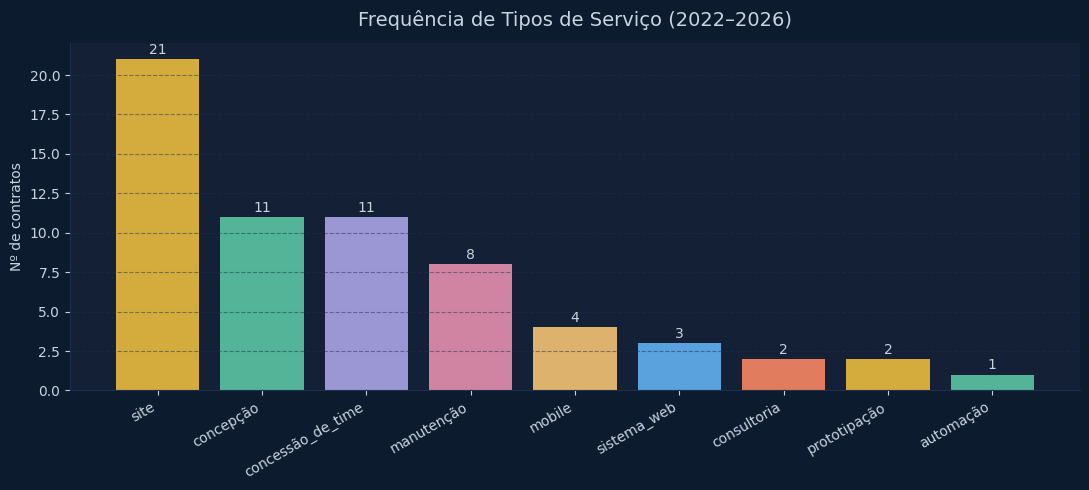

In [ ]:

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

freq = df["servico"].value_counts().reset_index()
freq.columns = ["servico","count"]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(freq))]
bars = ax.bar(freq["servico"], freq["count"], color=colors, alpha=0.88)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            str(int(bar.get_height())), ha="center", va="bottom", color=TEXT, fontsize=10)
ax.set_title("Frequência de Tipos de Serviço (2022–2026)", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Nº de contratos", color=TEXT)
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y")
plt.tight_layout()
save("u5_frequencia_servicos")


### 1.6 Sazonalidade — faturamento médio por mês (todos os anos)

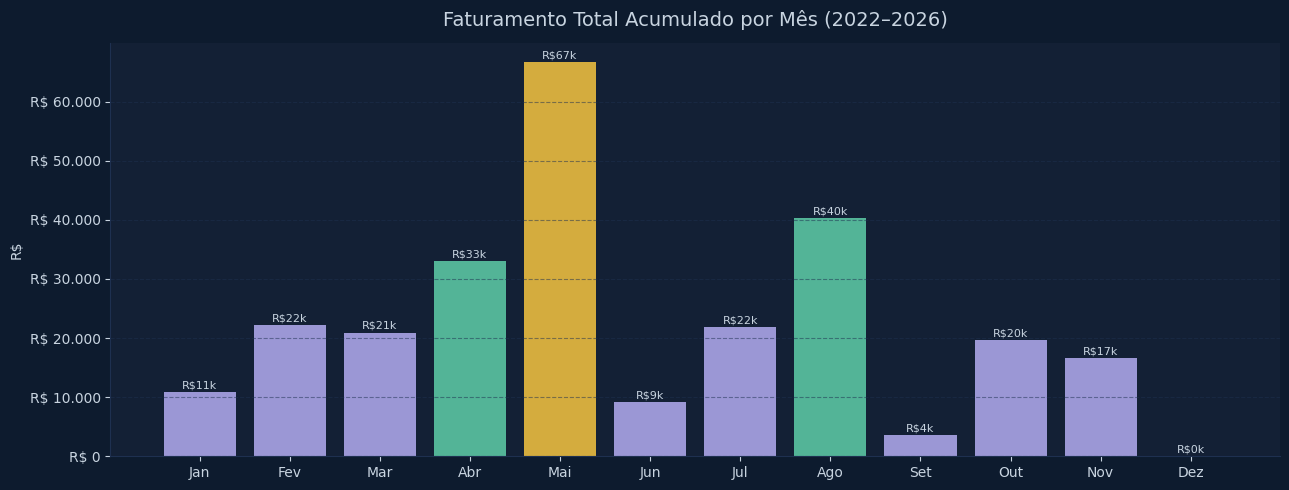

In [ ]:

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

saz = df.groupby("mes_num")["faturamento"].sum().reindex(range(1,13), fill_value=0)
nomes_mes = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
colors = [ACCENT if v == saz.max() else "#5DCAA5" if v >= saz.quantile(0.75) else PALETTE[2] for v in saz]
bars = ax.bar(nomes_mes, saz.values, color=colors, alpha=0.88)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f"R${bar.get_height()/1000:.0f}k", ha="center", va="bottom",
            color=TEXT, fontsize=8)
ax.set_title("Faturamento Total Acumulado por Mês (2022–2026)", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.grid(axis="y")
plt.tight_layout()
save("u6_sazonalidade")


### 1.7 Meses sem fechamento por ano

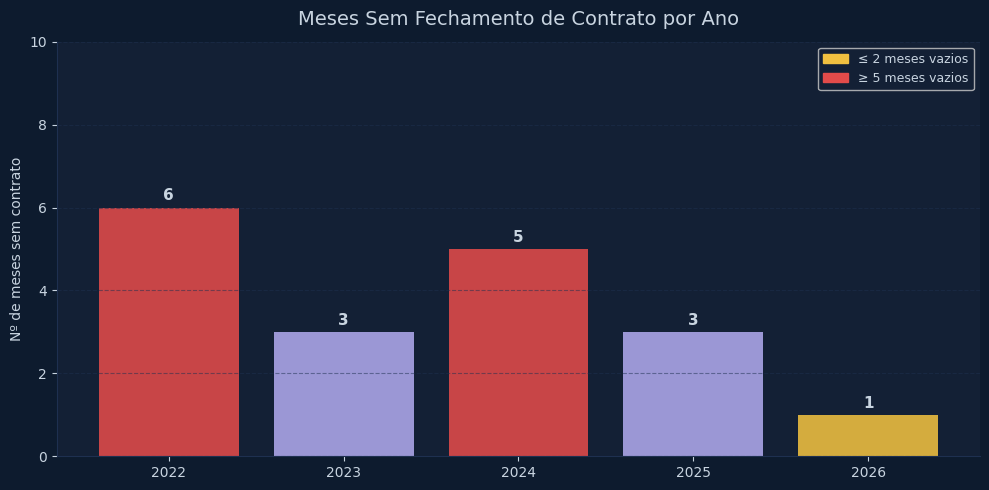

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

meses_com = df.groupby("ano")["mes_num"].nunique()
meses_max = {2022:12, 2023:12, 2024:12, 2025:12, 2026:6}
sem = {a: meses_max[a] - meses_com.get(a, 0) for a in sorted(metas.keys())}
anos_s = list(sem.keys())
vals_s = list(sem.values())
colors = ["#E24B4A" if v >= 5 else ACCENT if v <= 2 else PALETTE[2] for v in vals_s]
bars = ax.bar(anos_s, vals_s, color=colors, alpha=0.88)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(int(bar.get_height())), ha="center", va="bottom", color=TEXT, fontsize=11, fontweight="bold")
ax.set_title("Meses Sem Fechamento de Contrato por Ano", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Nº de meses sem contrato", color=TEXT)
ax.set_ylim(0, 10)
ax.grid(axis="y")
note = mpatches.Patch(color="#E24B4A", label="≥ 5 meses vazios")
good = mpatches.Patch(color=ACCENT, label="≤ 2 meses vazios")
ax.legend(handles=[good, note], fontsize=9)
plt.tight_layout()
save("u7_meses_sem_contrato")


### 1.8 Mix de serviços por ano — participação no faturamento (%)

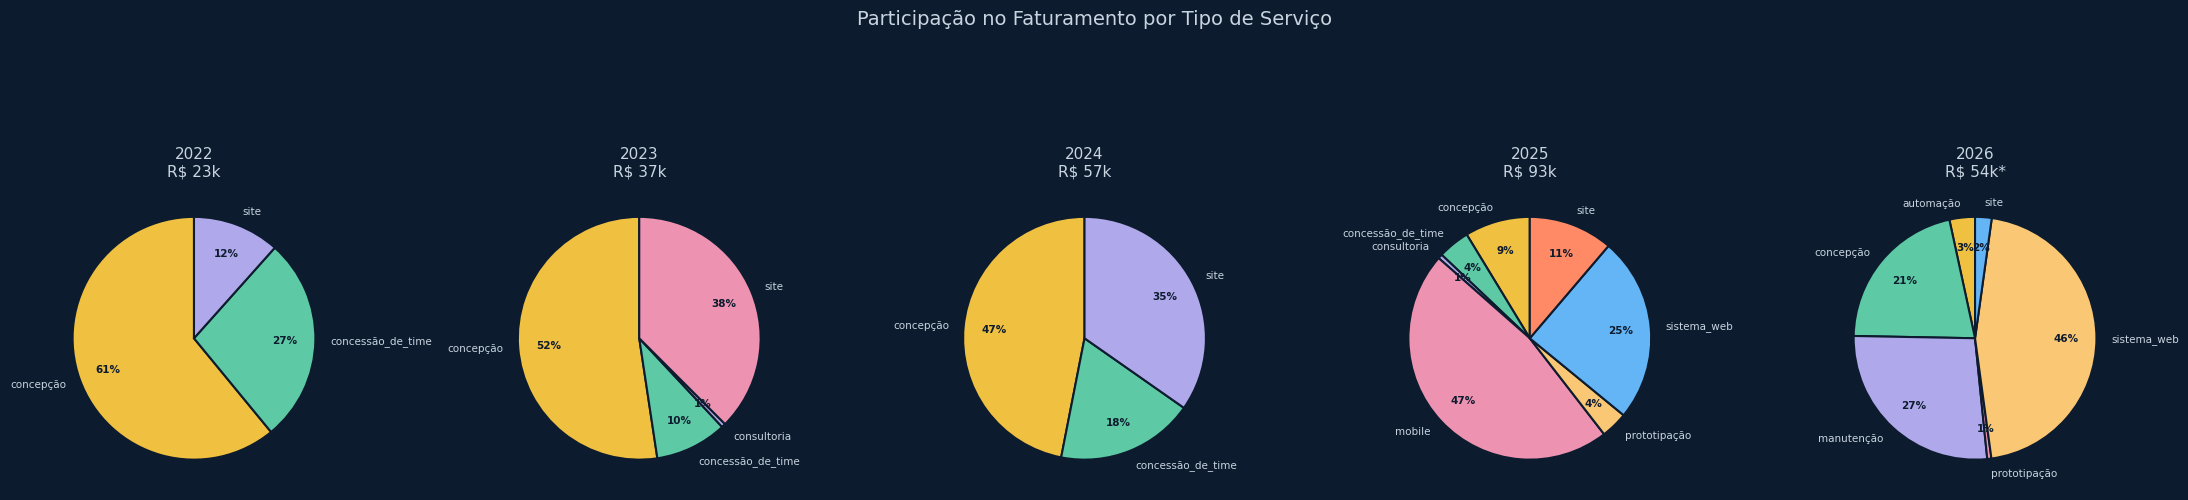

In [ ]:

anos_plot = [2022, 2023, 2024, 2025, 2026]
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Participação no Faturamento por Tipo de Serviço", color=TEXT, fontsize=14, y=1.02)

for ax, ano in zip(axes, anos_plot):
    ax.set_facecolor(BG)
    sub = df[df["ano"]==ano].groupby("servico")["faturamento"].sum()
    total = sub.sum()
    colors_pie = [PALETTE[i % len(PALETTE)] for i in range(len(sub))]
    wedges, texts, autotexts = ax.pie(
        sub.values, labels=sub.index, autopct="%1.0f%%",
        colors=colors_pie, startangle=90,
        pctdistance=0.75, labeldistance=1.12,
        textprops={"color": TEXT, "fontsize": 7.5},
        wedgeprops={"edgecolor": BG, "linewidth": 1.5}
    )
    for at in autotexts:
        at.set_color(BG)
        at.set_fontsize(7.5)
        at.set_fontweight("bold")
    fat_str = f"R$ {total/1000:.0f}k" if ano != 2026 else f"R$ {total/1000:.0f}k*"
    ax.set_title(f"{ano}\n{fat_str}", color=TEXT, fontsize=11, pad=8)

plt.tight_layout()
save("u8_pizza_servicos_por_ano")


### 1.9 Mix de origens por ano — participação no faturamento (%)

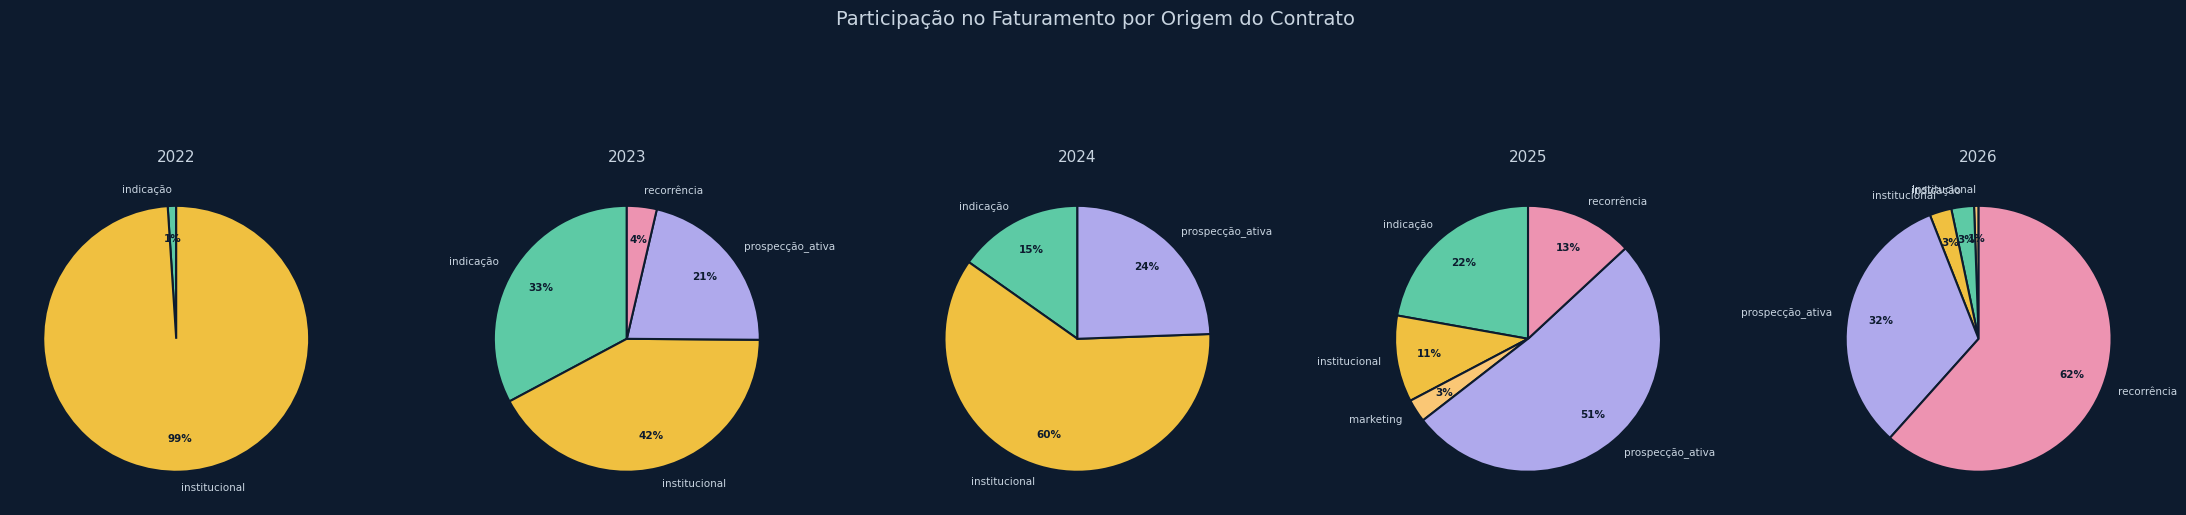

In [ ]:

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Participação no Faturamento por Origem do Contrato", color=TEXT, fontsize=14, y=1.02)

for ax, ano in zip(axes, anos_plot):
    ax.set_facecolor(BG)
    sub = df[df["ano"]==ano].groupby("origem")["faturamento"].sum()
    colors_pie = [ORI_COL.get(o, PALETTE[4]) for o in sub.index]
    wedges, texts, autotexts = ax.pie(
        sub.values, labels=sub.index, autopct="%1.0f%%",
        colors=colors_pie, startangle=90,
        pctdistance=0.75, labeldistance=1.12,
        textprops={"color": TEXT, "fontsize": 7.5},
        wedgeprops={"edgecolor": BG, "linewidth": 1.5}
    )
    for at in autotexts:
        at.set_color(BG); at.set_fontsize(7.5); at.set_fontweight("bold")
    ax.set_title(f"{ano}", color=TEXT, fontsize=11, pad=8)

plt.tight_layout()
save("u9_pizza_origens_por_ano")


### 1.10 Quantidade de contratos por tipo de serviço (por ano)

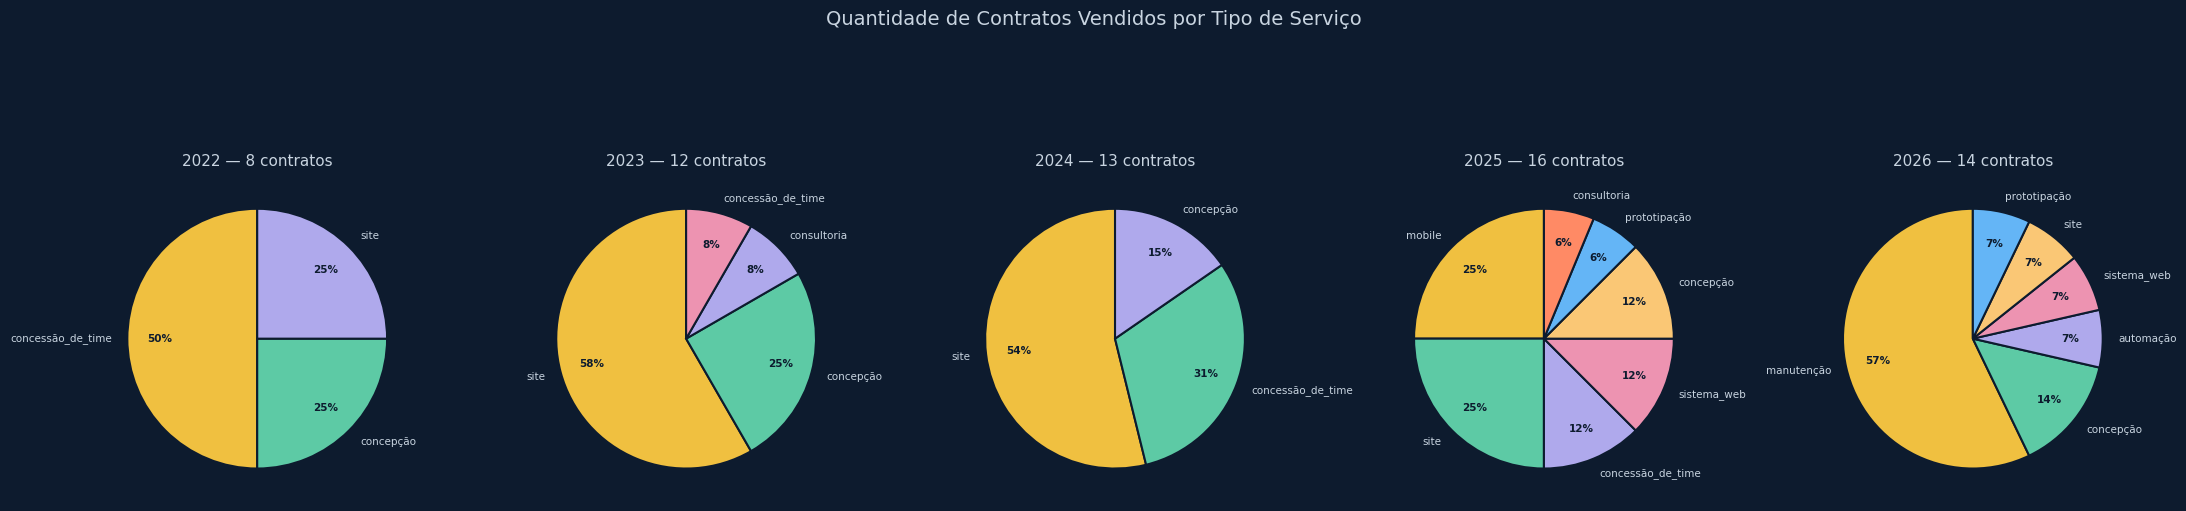

In [ ]:

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Quantidade de Contratos Vendidos por Tipo de Serviço", color=TEXT, fontsize=14, y=1.02)

for ax, ano in zip(axes, anos_plot):
    ax.set_facecolor(BG)
    sub = df[df["ano"]==ano]["servico"].value_counts()
    colors_pie = [PALETTE[i % len(PALETTE)] for i in range(len(sub))]
    wedges, texts, autotexts = ax.pie(
        sub.values, labels=sub.index, autopct="%1.0f%%",
        colors=colors_pie, startangle=90,
        pctdistance=0.75, labeldistance=1.12,
        textprops={"color": TEXT, "fontsize": 7.5},
        wedgeprops={"edgecolor": BG, "linewidth": 1.5}
    )
    for at in autotexts:
        at.set_color(BG); at.set_fontsize(7.5); at.set_fontweight("bold")
    ax.set_title(f"{ano} — {len(df[df['ano']==ano])} contratos", color=TEXT, fontsize=11, pad=8)

plt.tight_layout()
save("u10_pizza_qtd_contratos_por_ano")


---
## 2. Análise Bivariada e Multivariada
> Cruzamento entre variáveis — mix, origem, sazonalidade, colaborativo e ritmo.


### 2.1 Curvas de faturamento acumulado por ano (com ritmo significativo)

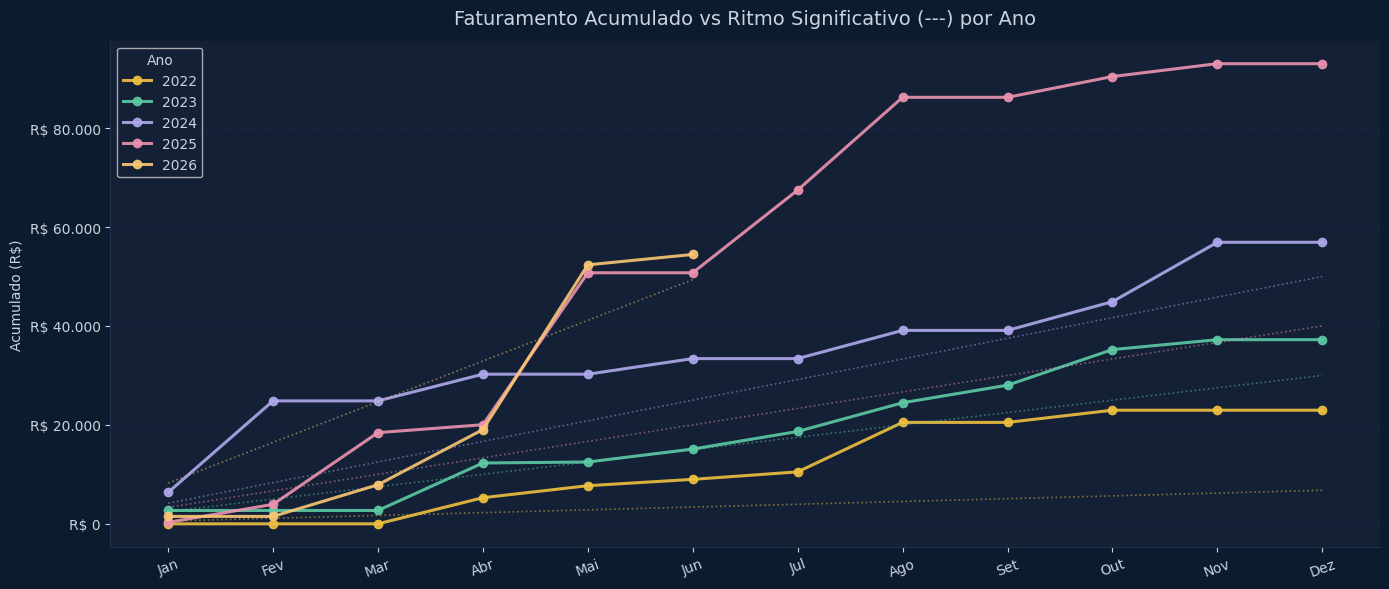

In [ ]:

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

meses_label = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

for i, ano in enumerate(sorted(metas.keys())):
    sub = df[df["ano"]==ano].copy()
    acum = []
    total = 0
    for m in range(1, 13):
        total += sub[sub["mes_num"]==m]["faturamento"].sum()
        acum.append(total)
    n_meses = 6 if ano == 2026 else 12
    ax.plot(meses_label[:n_meses], acum[:n_meses],
            marker="o", color=PALETTE[i], linewidth=2.2,
            markersize=6, label=str(ano), alpha=0.9)
    # ritmo
    r = ritmo[ano]
    ax.plot(meses_label[:n_meses], r[:n_meses],
            linestyle=":", color=PALETTE[i], linewidth=1.2, alpha=0.5)

ax.set_title("Faturamento Acumulado vs Ritmo Significativo (---) por Ano",
             color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Acumulado (R$)", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(title="Ano", fontsize=10, title_fontsize=10)
ax.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
save("b1_curvas_acumuladas")


### 2.2 Composição do faturamento anual por tipo de serviço

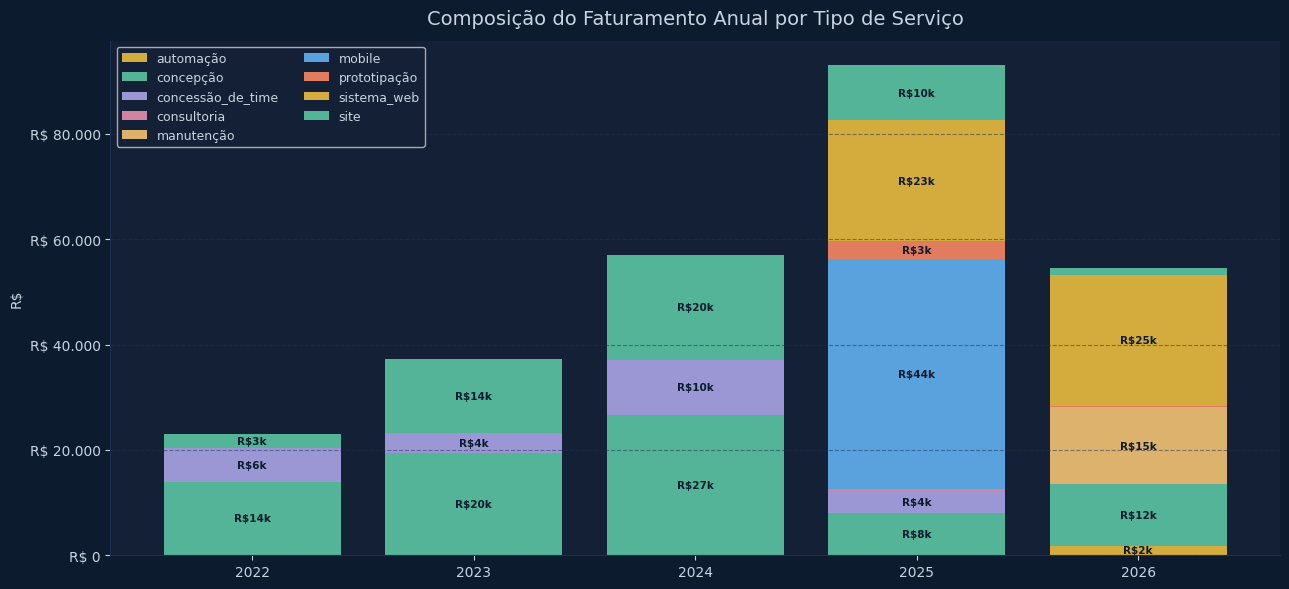

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

pivot = df.pivot_table(index="ano", columns="servico", values="faturamento",
                       aggfunc="sum", fill_value=0)
servicos = pivot.columns.tolist()
bottom = np.zeros(len(pivot))
anos_idx = pivot.index.tolist()

for i, serv in enumerate(servicos):
    vals = pivot[serv].values
    bars = ax.bar(anos_idx, vals, bottom=bottom,
                  label=serv, color=PALETTE[i % len(PALETTE)], alpha=0.88)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 1500:
            ax.text(bar.get_x()+bar.get_width()/2, bot + val/2,
                    f"R${val/1000:.0f}k", ha="center", va="center",
                    color=BG, fontsize=7.5, fontweight="bold")
    bottom += vals

ax.set_title("Composição do Faturamento Anual por Tipo de Serviço",
             color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y")
plt.tight_layout()
save("b2_composicao_servicos")


### 2.3 Distribuição de valores por tipo de serviço

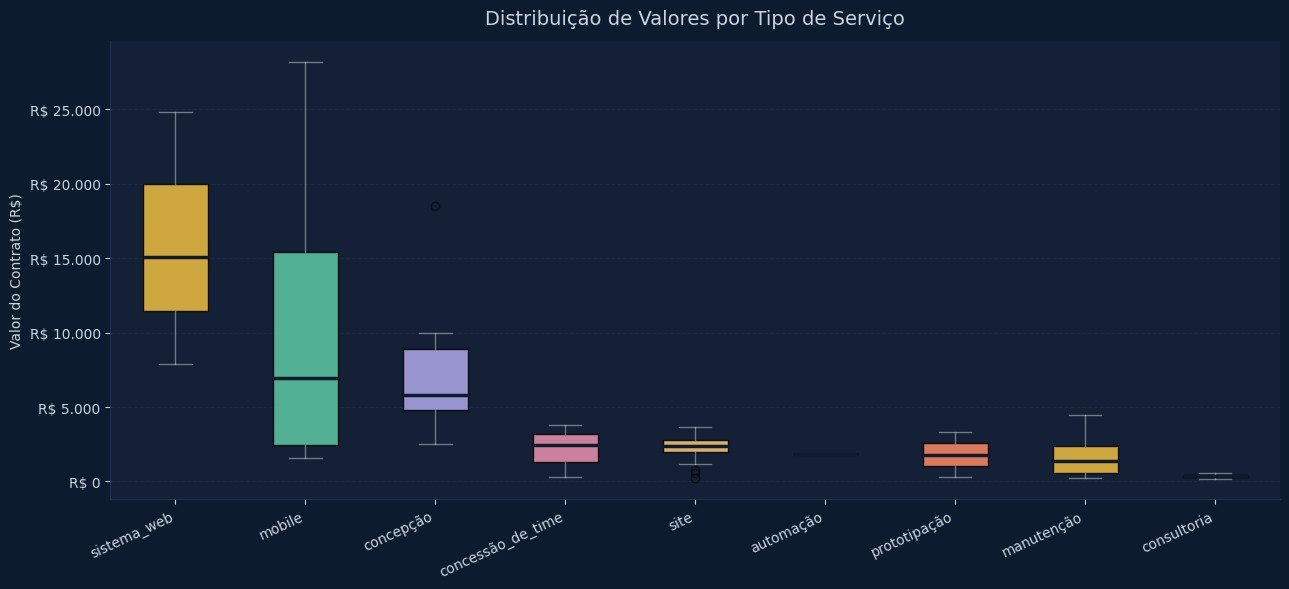

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

order = df.groupby("servico")["faturamento"].median().sort_values(ascending=False).index
data_box = [df[df["servico"]==s]["faturamento"].values for s in order]
bp = ax.boxplot(data_box, patch_artist=True, labels=order,
                medianprops=dict(color=BG, linewidth=2.5))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(PALETTE[i % len(PALETTE)])
    patch.set_alpha(0.85)
for element in ["whiskers","caps","fliers"]:
    for item in bp[element]:
        item.set_color(TEXT); item.set_alpha(0.5)
ax.set_title("Distribuição de Valores por Tipo de Serviço", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Valor do Contrato (R$)", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
plt.xticks(rotation=25, ha="right")
ax.grid(axis="y")
plt.tight_layout()
save("b3_boxplot_servico")


### 2.4 Ticket médio e distribuição por origem

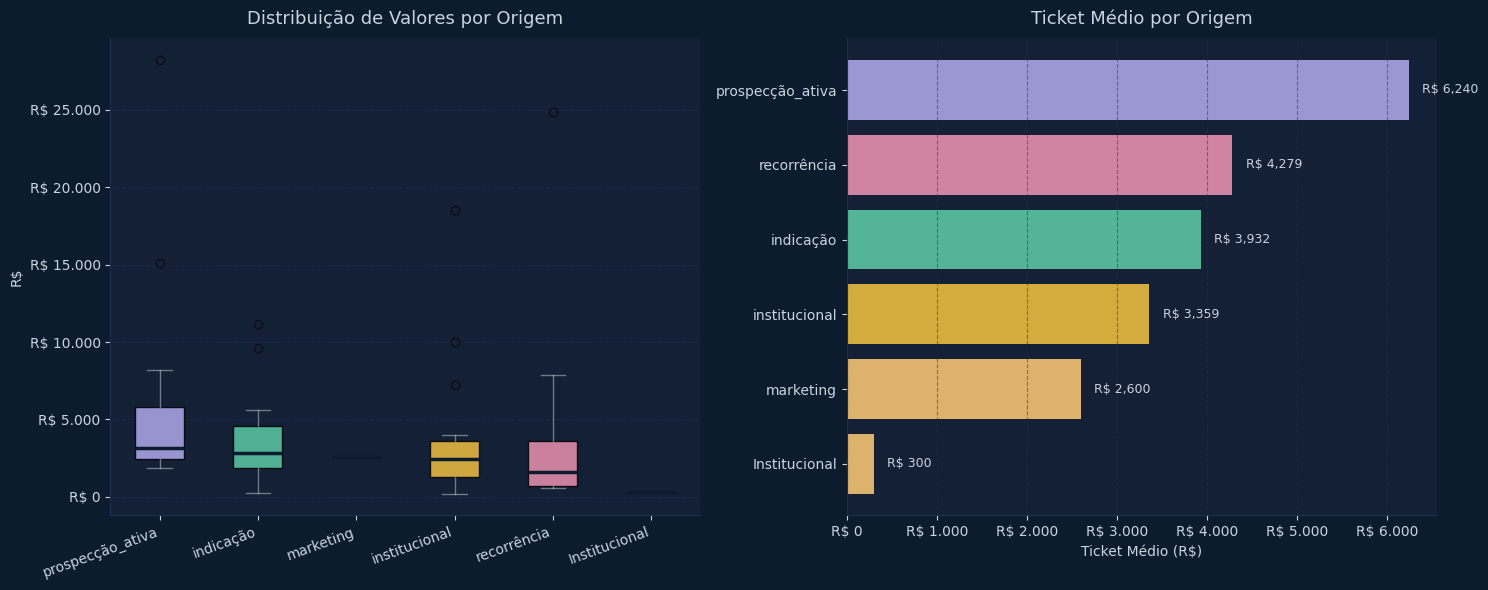

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)

# Boxplot
ax = axes[0]
ax.set_facecolor(CARD)
order_ori = df.groupby("origem")["faturamento"].median().sort_values(ascending=False).index
data_ori = [df[df["origem"]==o]["faturamento"].values for o in order_ori]
bp = ax.boxplot(data_ori, patch_artist=True, labels=order_ori,
                medianprops=dict(color=BG, linewidth=2.5))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(ORI_COL.get(list(order_ori)[i], PALETTE[4]))
    patch.set_alpha(0.85)
for element in ["whiskers","caps","fliers"]:
    for item in bp[element]:
        item.set_color(TEXT); item.set_alpha(0.5)
ax.set_title("Distribuição de Valores por Origem", color=TEXT, fontsize=13, pad=10)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
ax.grid(axis="y")

# Ticket médio por origem
ax2 = axes[1]
ax2.set_facecolor(CARD)
tm_ori = df.groupby("origem")["faturamento"].mean().sort_values(ascending=True)
colors_ori = [ORI_COL.get(o, PALETTE[4]) for o in tm_ori.index]
bars = ax2.barh(tm_ori.index, tm_ori.values, color=colors_ori, alpha=0.88)
for bar, val in zip(bars, tm_ori.values):
    ax2.text(val+150, bar.get_y()+bar.get_height()/2,
             f"R$ {val:,.0f}", va="center", color=TEXT, fontsize=9)
ax2.set_title("Ticket Médio por Origem", color=TEXT, fontsize=13, pad=10)
ax2.set_xlabel("Ticket Médio (R$)", color=TEXT)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax2.grid(axis="x")

plt.tight_layout()
save("b4_origem_faturamento")


### 2.5 Heatmap — Origem × Tipo de Serviço (faturamento total)

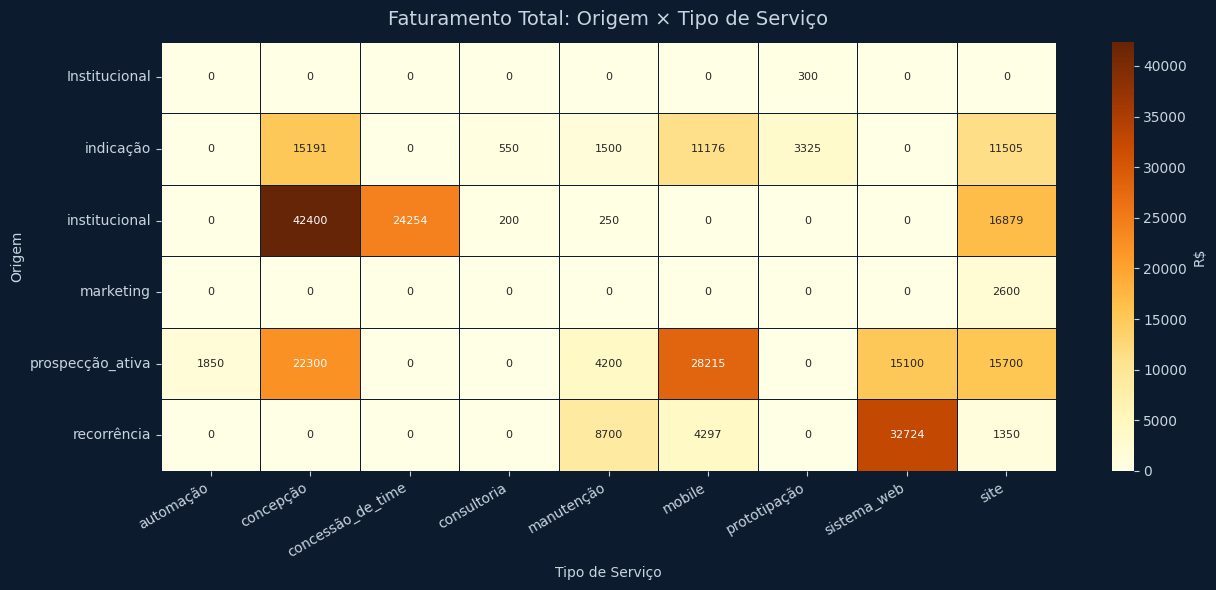

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

heat = df.pivot_table(index="origem", columns="servico",
                      values="faturamento", aggfunc="sum", fill_value=0)
sns.heatmap(heat, ax=ax, cmap="YlOrBr", annot=True, fmt=".0f",
            linewidths=0.5, linecolor=BG,
            cbar_kws={"label":"R$"},
            annot_kws={"size": 8})
ax.set_title("Faturamento Total: Origem × Tipo de Serviço", color=TEXT, fontsize=14, pad=12)
ax.set_xlabel("Tipo de Serviço", color=TEXT)
ax.set_ylabel("Origem", color=TEXT)
plt.xticks(rotation=30, ha="right", color=TEXT)
plt.yticks(color=TEXT)
plt.tight_layout()
save("b5_heatmap_origem_servico")


### 2.6 Colaborativo vs Não-colaborativo

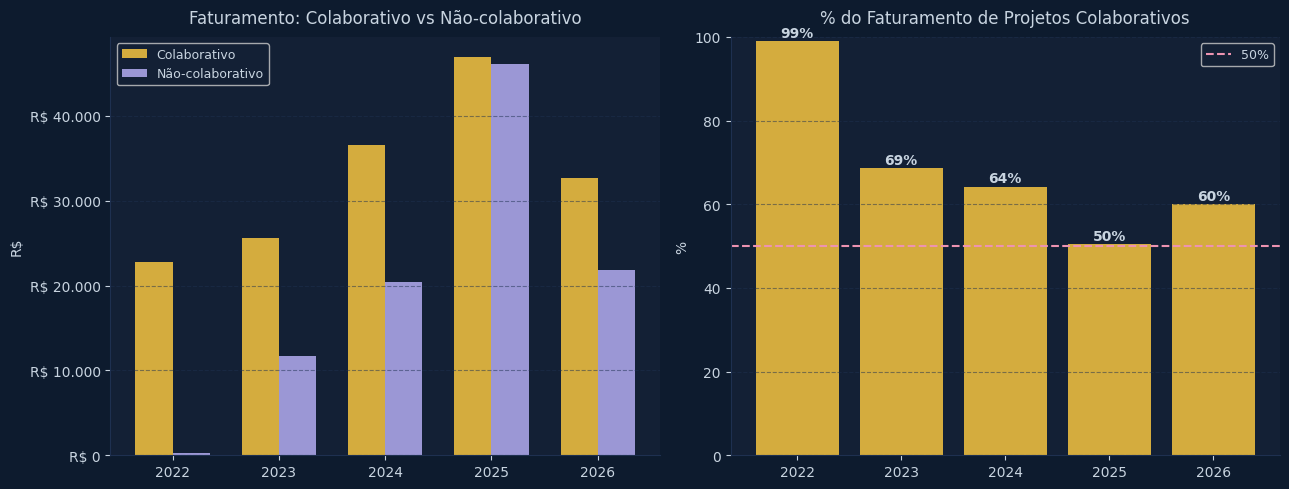

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)

# Faturamento total
ax = axes[0]
ax.set_facecolor(CARD)
colab = df.groupby(["ano","colaborativo"])["faturamento"].sum().unstack(fill_value=0)
if 0 in colab.columns and 1 in colab.columns:
    x = np.arange(len(colab.index))
    w = 0.35
    ax.bar(x-w/2, colab[1], w, label="Colaborativo", color=ACCENT, alpha=0.88)
    ax.bar(x+w/2, colab[0], w, label="Não-colaborativo", color=PALETTE[2], alpha=0.88)
    ax.set_xticks(x); ax.set_xticklabels(colab.index)
ax.set_title("Faturamento: Colaborativo vs Não-colaborativo", color=TEXT, fontsize=12, pad=10)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(fontsize=9)
ax.grid(axis="y")

# % colaborativo por ano
ax2 = axes[1]
ax2.set_facecolor(CARD)
pct_vals = (colab[1] / (colab[0]+colab[1]) * 100)
ax2.bar(pct_vals.index, pct_vals.values, color=ACCENT, alpha=0.88)
ax2.axhline(50, color="#ED93B1", linestyle="--", linewidth=1.5, label="50%")
for ano_v, val in pct_vals.items():
    ax2.text(ano_v, val+1, f"{val:.0f}%",
             ha="center", color=TEXT, fontsize=10, fontweight="bold")
ax2.set_title("% do Faturamento de Projetos Colaborativos", color=TEXT, fontsize=12, pad=10)
ax2.set_ylabel("%", color=TEXT)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.grid(axis="y")

plt.tight_layout()
save("b6_colaborativo")


### 2.7 Dispersão — mês de fechamento × valor do contrato

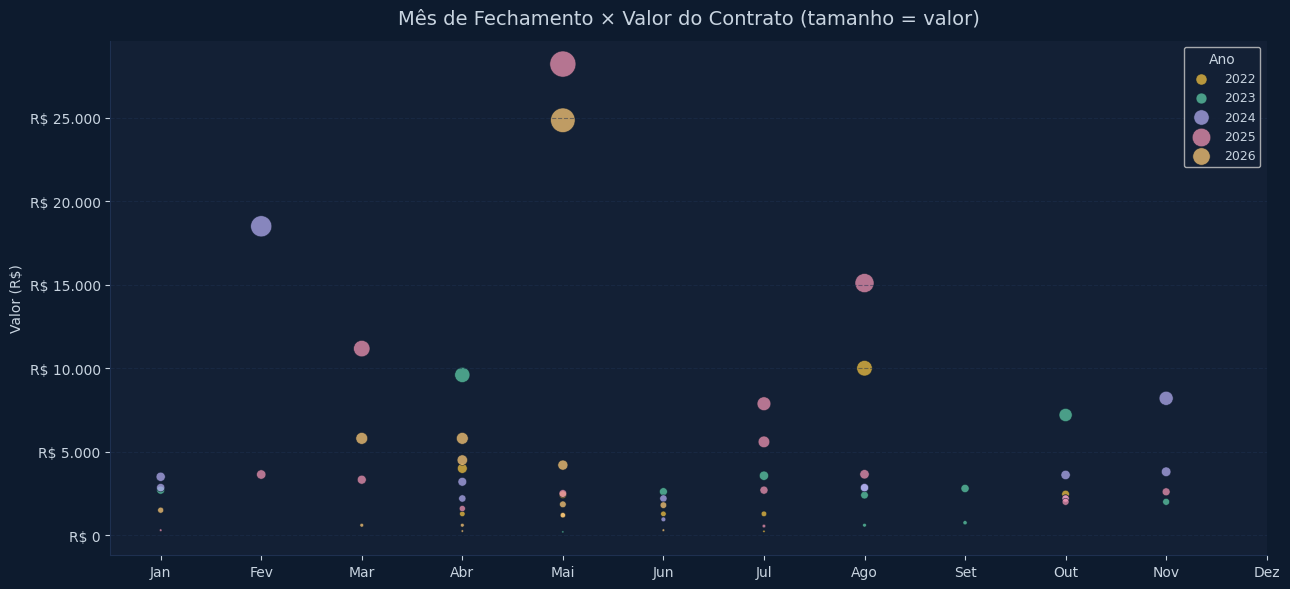

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

for i, ano in enumerate(sorted(df["ano"].unique())):
    sub = df[df["ano"]==ano]
    ax.scatter(sub["mes_num"], sub["faturamento"],
               color=PALETTE[i], label=str(ano),
               s=sub["faturamento"]/80, alpha=0.75, edgecolors=BG, linewidth=0.5)

ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
ax.set_title("Mês de Fechamento × Valor do Contrato (tamanho = valor)",
             color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Valor (R$)", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(title="Ano", fontsize=9, title_fontsize=10)
ax.grid(axis="y")
plt.tight_layout()
save("b7_dispersao_mes_valor")


### 2.8 Composição do faturamento anual por origem

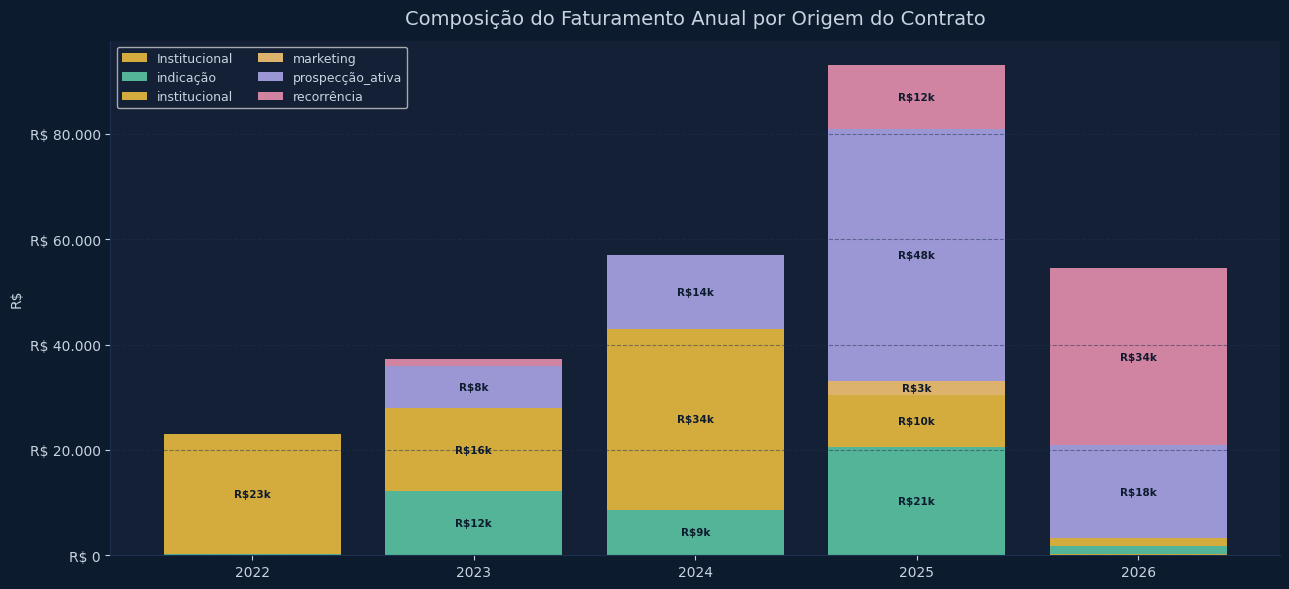

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

pivot_ori = df.pivot_table(index="ano", columns="origem", values="faturamento",
                           aggfunc="sum", fill_value=0)
bottom = np.zeros(len(pivot_ori))
origens_cols = pivot_ori.columns.tolist()

for i, ori in enumerate(origens_cols):
    vals = pivot_ori[ori].values
    bars = ax.bar(pivot_ori.index, vals, bottom=bottom,
                  label=ori, color=ORI_COL.get(ori, PALETTE[i % len(PALETTE)]), alpha=0.88)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 2000:
            ax.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                    f"R${val/1000:.0f}k", ha="center", va="center",
                    color=BG, fontsize=7.5, fontweight="bold")
    bottom += vals

ax.set_title("Composição do Faturamento Anual por Origem do Contrato",
             color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("R$", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y")
plt.tight_layout()
save("b8_composicao_origens")


### 2.9 Evolução do ticket médio por tipo de serviço ao longo dos anos

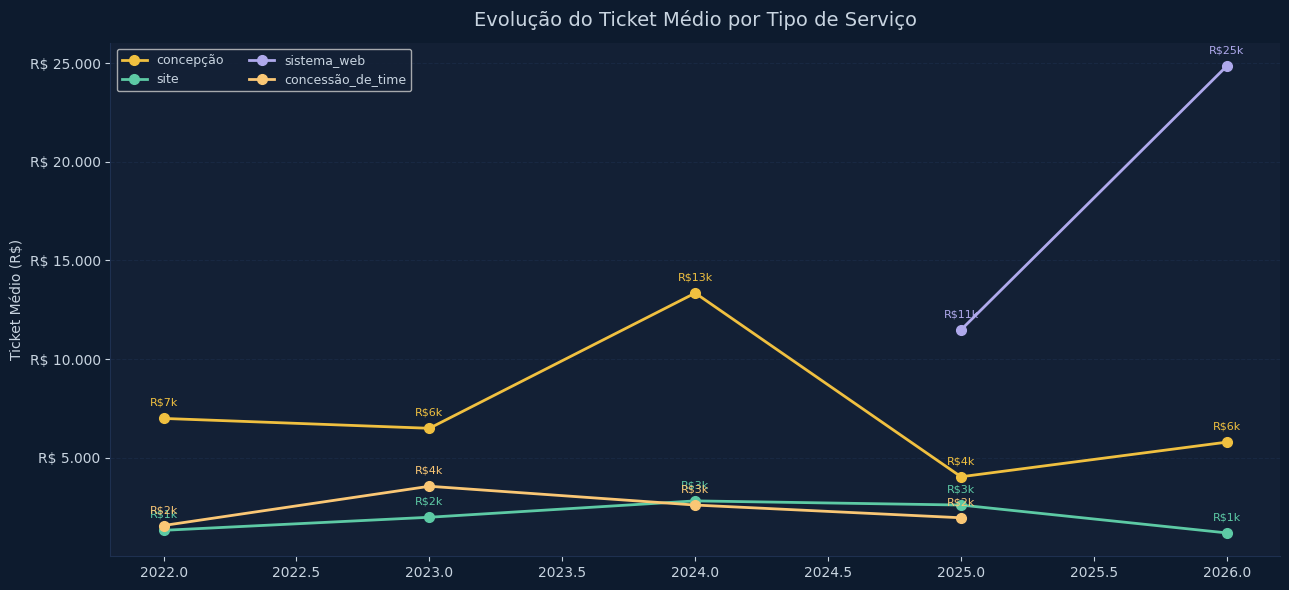

In [ ]:

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

top_servicos = df.groupby("servico")["faturamento"].sum().nlargest(6).index
for i, serv in enumerate(top_servicos):
    sub = df[df["servico"]==serv].groupby("ano")["faturamento"].mean().reset_index()
    if len(sub) >= 2:
        ax.plot(sub["ano"], sub["faturamento"], marker="o",
                color=PALETTE[i], linewidth=2, markersize=7, label=serv)
        for _, row in sub.iterrows():
            ax.annotate(f"R${row['faturamento']/1000:.0f}k",
                        (row["ano"], row["faturamento"]),
                        textcoords="offset points", xytext=(0,9),
                        ha="center", color=PALETTE[i], fontsize=8)

ax.set_title("Evolução do Ticket Médio por Tipo de Serviço", color=TEXT, fontsize=14, pad=12)
ax.set_ylabel("Ticket Médio (R$)", color=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.legend(fontsize=9, ncol=2)
ax.grid(axis="y")
plt.tight_layout()
save("b9_ticket_servico_evolucao")


### 2.10 Número de contratos vs Faturamento total por ano

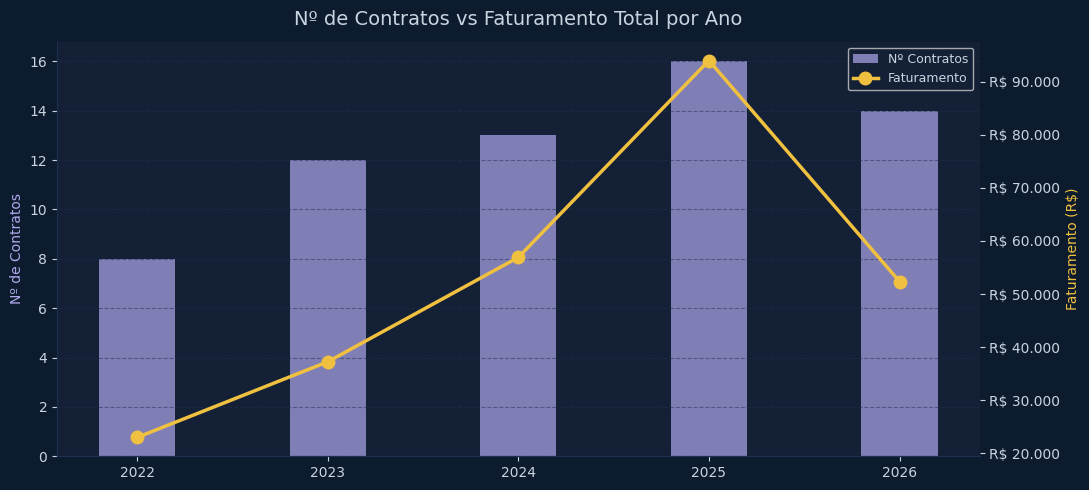

In [ ]:

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)
ax2 = ax.twinx()
ax2.set_facecolor(CARD)

anos_s = sorted(metas.keys())
n_contratos = [len(df[df["ano"]==a]) for a in anos_s]
fat_ano = [metas[a].get("faturamento_total", metas[a].get("faturamento_total_ate_momento")) for a in anos_s]

ax.bar(anos_s, n_contratos, color=PALETTE[2], alpha=0.7, label="Nº Contratos", width=0.4)
ax2.plot(anos_s, fat_ano, color=ACCENT, marker="o", linewidth=2.5, markersize=9, label="Faturamento")

ax.set_ylabel("Nº de Contratos", color=PALETTE[2])
ax2.set_ylabel("Faturamento (R$)", color=ACCENT)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title("Nº de Contratos vs Faturamento Total por Ano", color=TEXT, fontsize=14, pad=12)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax.grid(axis="y")
plt.tight_layout()
save("b10_contratos_vs_faturamento")


### 2.11 Taxa de Fidelização: Novos Leads vs. Clientes Recorrentes
> Esta análise identifica quantos contratos em cada ano vieram de clientes que já haviam fechado com a Seed a Bit em anos anteriores.

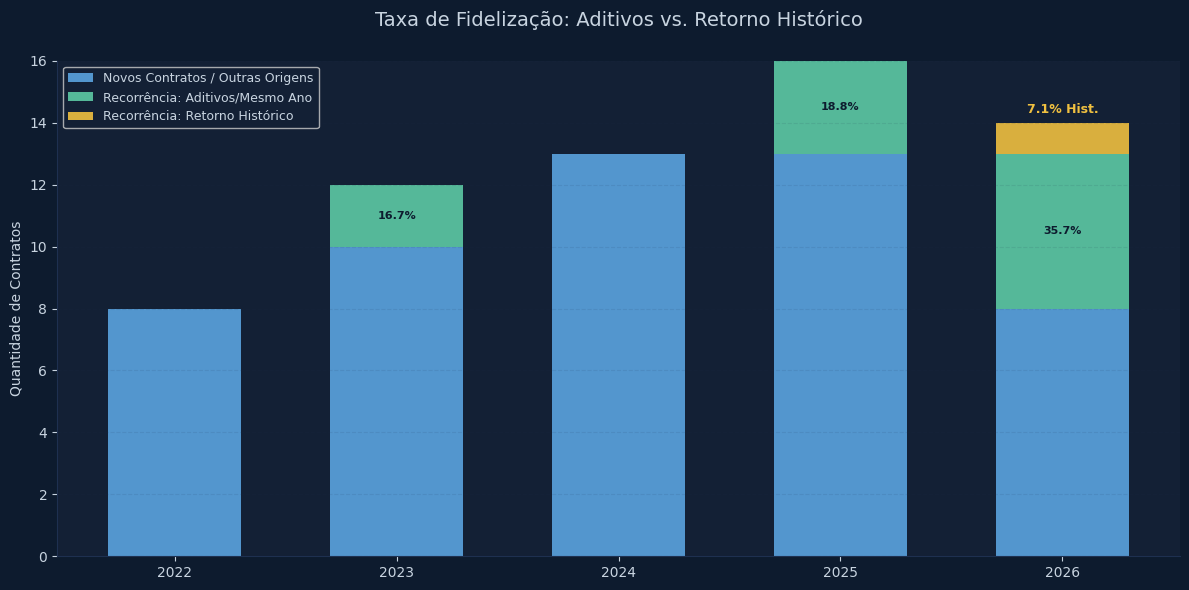

In [ ]:
def check_loyalty_refined(df):
    loyalty_data = []
    anos_sorted = sorted(df['ano'].unique())
    clientes_vistos_antes_do_ano = set()

    # Ordenação cronológica para rastrear histórico
    df_sorted = df.sort_values(['ano', 'mes_num']).copy()

    for ano in anos_sorted:
        df_ano = df_sorted[df_sorted['ano'] == ano]
        total_contratos = len(df_ano)

        qtd_retornando_anos_anteriores = 0
        qtd_recorrencia_mesmo_ano = 0
        qtd_outras_origens = 0

        clientes_vistos_neste_ano = set()

        for _, row in df_ano.iterrows():
            c = row['cliente']
            origem = str(row['origem']).lower().strip()

            if origem == "recorrência":
                if c in clientes_vistos_antes_do_ano:
                    qtd_retornando_anos_anteriores += 1
                else:
                    qtd_recorrencia_mesmo_ano += 1
            else:
                qtd_outras_origens += 1

            clientes_vistos_neste_ano.add(c)

        loyalty_data.append({
            'ano': ano,
            'Outras Origens': qtd_outras_origens,
            'Recorrência (Mesmo Ano)': qtd_recorrencia_mesmo_ano,
            'Recorrência (Anos Anteriores)': qtd_retornando_anos_anteriores,
            'total': total_contratos
        })

        clientes_vistos_antes_do_ano.update(clientes_vistos_neste_ano)

    return pd.DataFrame(loyalty_data)

if 'df' in globals():
    df_loyalty = check_loyalty_refined(df)

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(CARD)

    width = 0.6
    ax.bar(df_loyalty['ano'], df_loyalty['Outras Origens'], width,
           label='Novos Contratos / Outras Origens', color=PALETTE[5], alpha=0.8)

    ax.bar(df_loyalty['ano'], df_loyalty['Recorrência (Mesmo Ano)'], width,
           bottom=df_loyalty['Outras Origens'],
           label='Recorrência: Aditivos/Mesmo Ano', color="#5DCAA5", alpha=0.9)

    ax.bar(df_loyalty['ano'], df_loyalty['Recorrência (Anos Anteriores)'], width,
           bottom=df_loyalty['Outras Origens'] + df_loyalty['Recorrência (Mesmo Ano)'],
           label='Recorrência: Retorno Histórico', color=ACCENT, alpha=0.9)

    for i, row in df_loyalty.iterrows():
        total = row['total']
        if total > 0:
            pct_mesmo_ano = (row['Recorrência (Mesmo Ano)'] / total) * 100
            pct_hist = (row['Recorrência (Anos Anteriores)'] / total) * 100

            # Rótulo interno para Recorrência no Mesmo Ano (Ciano)
            if row['Recorrência (Mesmo Ano)'] > 0:
                ax.text(row['ano'], row['Outras Origens'] + row['Recorrência (Mesmo Ano)']/2, f"{pct_mesmo_ano:.1f}%",
                        ha='center', va='center', color=BG, fontsize=8, fontweight='bold')

            # Rótulo superior para Retorno Histórico (Laranja)
            if row['Recorrência (Anos Anteriores)'] > 0:
                ax.text(row['ano'], total + 0.3, f"{pct_hist:.1f}% Hist.",
                        ha='center', color=ACCENT, fontsize=9, fontweight='bold')

    ax.set_title("Taxa de Fidelização: Aditivos vs. Retorno Histórico", color=TEXT, fontsize=14, pad=25)
    ax.set_ylabel("Quantidade de Contratos", color=TEXT)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.1)

    plt.tight_layout()
    save("b11_fidelizacao_por_origem")

---
## 3. Insights Comerciais
> Síntese analítica dos padrões identificados na EDA.



### 3.1 Crescimento e Maturidade Comercial

A Seed a Bit acumulou **R$ 264.266.46** em faturamento entre 2022 e 2026 (parcial), saindo de 22.968,66 para um ritmo que projeta R$ 98.715 em 2026 — um crescimento de **329% em 4 anos**. O mais revelador, porém, não é o número absoluto, mas a mudança no padrão: em 2022 a EJ faturou 338% da meta com apenas 8 contratos. Em 2025, faturou 237% da meta com 16 contratos. Isso indica que o crescimento está sendo acompanhado por uma diversificação real da carteira — e não por dependência de um único projeto grande.

### 3.2 O Efeito dos Projetos de Alto Valor

Em todos os anos, 1 ou 2 contratos foram responsáveis por mais de 30% do faturamento total. Em 2022, a **Alpha Tech Assoc.** (R$ 10k) representou 43% do ano. Em 2024, a **Fenix Research** (R$ 18,5k) representou 32%. Em 2025, **Health Plus** (R$ 28,2k) respondeu por 30% do faturamento. Esse padrão é tanto um ponto forte (capacidade de fechar contratos grandes) quanto um risco estrutural — um único cancelamento derruba o ano.

### 3.3 Origem dos Contratos: Predominância Institucional em Declínio

Entre 2022 e 2024, a origem **institucional** dominou o faturamento. Em 2022, 100% dos contratos vieram de relações institucionais. Em 2023 e 2024, a prospecção ativa começou a aparecer. Em 2025, a diversificação se consolida com indicação, recorrência, marketing e prospecção ativa todos presentes. Isso é um sinal positivo de maturidade comercial — a EJ está reduzindo dependência de uma única fonte.

### 3.4 Recorrência: o Canal que Mais Cresceu

A recorrência (clientes que voltam) aparece como origem significativa pela primeira vez em 2023 e cresce de forma consistente. Em 2026, já responde por uma parcela relevante do faturamento — puxada por **BioCare Med**, **Prime Development** e **Carlos Eduardo**. Recorrência tem custo de aquisição zero e tende a ter ticket crescente.

### 3.5 Sazonalidade: Agosto, Maio e Outubro são os Meses-chave

Historicamente, esses três meses concentram os maiores volumes de faturamento acumulado. Janeiro e setembro são os meses mais fracos — geralmente sem nenhum fechamento. A hipóteses estruturais precisam ser combatidas com pipeline ativo nesses períodos.

### 3.6 Mix de Serviços: Transição de Concepção para Desenvolvimento

Em 2022-2023, **concepção** e **concessão de time** dominavam. Em 2024, concepção ainda puxou o faturamento mas sites ganharam volume. Em 2025, **mobile** e **sistema web** aparecem pela primeira vez e já respondem por 77% do faturamento — indicando uma virada técnica real na capacidade de entrega da EJ.

### 3.7 Ticket Médio: Crescimento Consistente mas com Distorção

O ticket médio geral cresceu de R$ 2.871 (2022) para R$ 8.801 (2025), um aumento de 206%. Porém, essa média é fortemente puxada pelos contratos de sistema web e mobile. O ticket dos projetos de site praticamente não cresceu ao longo dos anos. Isso sugere que a Seed está precificando sites abaixo do potencial de mercado.

### 3.8 Projetos Colaborativos: Queda na Participação

Em 2022, 87% dos contratos eram colaborativos. Em 2025-2026, esse índice caiu significativamente. Isso pode indicar que a EJ ganhou capacidade de executar projetos próprios de ponta a ponta.

### 3.9 Ritmo Significativo: 2022 e 2024 Foram os Anos Mais Saudáveis

Em 2022, a Seed estava acima do ritmo significativo desde o primeiro contrato. Em 2024, manteve ritmo positivo em 11 dos 12 meses. Em 2025 specifically, a virada em maio (**Health Plus**) salvou o ano, mas isso reforça o risco da dependência de grandes contratos.

### 3.10 O que 2026 Sinaliza

Com R$ 52.350 em 6 meses, 2026 está no ritmo para superar metas anteriores. O dado mais relevante de 2026 é a predominância de **recorrência e manutenção** — 5 dos 14 contratos são de clientes que voltaram. Se isso se consolidar, a Seed terá finalmente um modelo de receita mais previsível.

### 3.11 Análise Histórica de Fidelização e Retenção (2022–2026)

*   **2022: Aquisição Pura:** O primeiro ano da série foca 100% em novos leads. Sem histórico prévio, todos os contratos são classificados como 'Outras Origens'.
*   **2023: Início da Recorrência:** A primeira demonstração de fidelidade surge com 8.3% de aditivos no mesmo ano.
*   **2024: Predomínio Institucional:** Apesar de atender clientes antigos, os contratos foram registrados como origem 'institucional'. Por isso, o gráfico de fidelidade (baseado na tag 'recorrência') aponta 0% de retenção, evidenciando que a EJ ainda tratava clientes antigos como novas vendas institucionais.
*   **2025: Consolidação de Aditivos:** Com 18.8% de fidelização interna, o ano foi pautado por expansões de escopo dentro do próprio exercício, mostrando cross-selling imediato.
*   **2026: Maturidade e Equilíbrio de Base:** O ano atual apresenta o melhor mix: 33.3% de aditivos no mesmo ano somados a 8.3% de retorno histórico. Aqui a Seed a Bit consolida a estratégia de manter o cliente ativo por mais tempo e com maior frequência.